# Customer Intelligence System
**Week 3 Assignment – Celebal Technologies Internship**

End-to-end pipeline: EDA &rarr; Clustering (K-Means, DBSCAN) &rarr; Ensemble Classification (Random Forest, XGBoost) &rarr; Segment Insights




## 2. Load the dataset





In [15]:
# --- manual upload ---
from google.colab import files
uploaded = files.upload()  # choose country-data.csv from the Kaggle dataset page
import io
import pandas as pd
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
df.head()

Saving Country-data.csv to Country-data.csv


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 3. Imports

In [16]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score
)
from xgboost import XGBClassifier

sns.set_style("whitegrid")
RANDOM_STATE = 42

## 4. Exploratory Data Analysis

In [17]:
print("Shape:", df.shape)
df.info()
df.describe().T

Shape: (167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


In [18]:
print("Missing values:\n", df.isnull().sum())

feature_cols = [
    "child_mort", "exports", "health", "imports", "income",
    "inflation", "life_expec", "total_fer", "gdpp"
]
X_raw = df[feature_cols].copy()

Missing values:
 country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


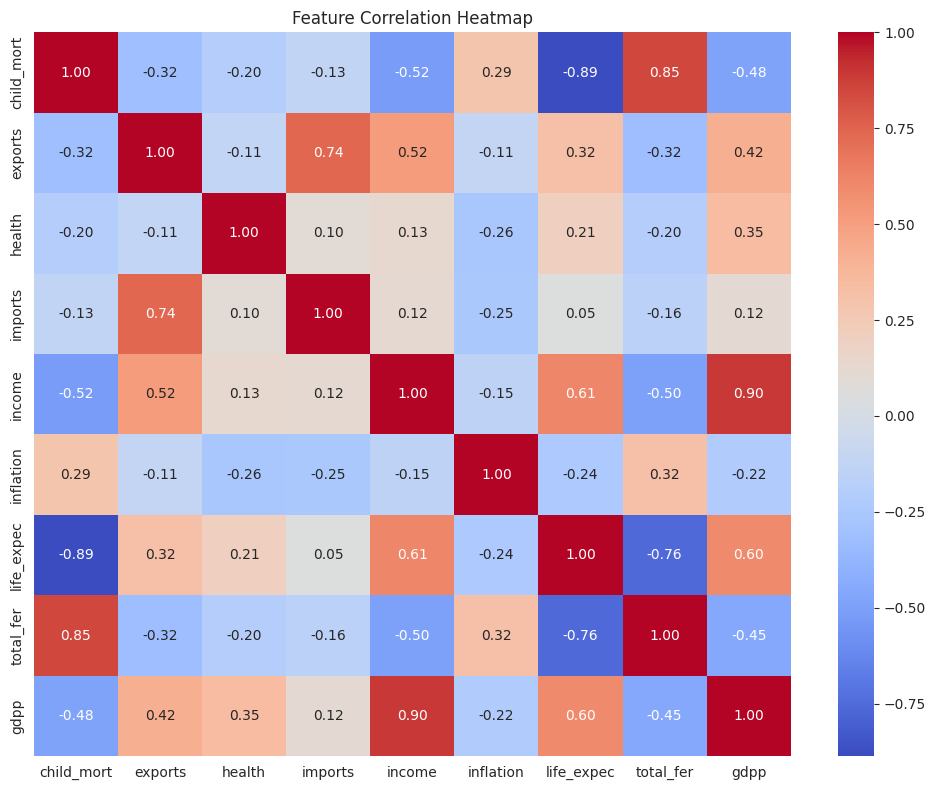

In [19]:
plt.figure(figsize=(10, 8))
sns.heatmap(X_raw.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

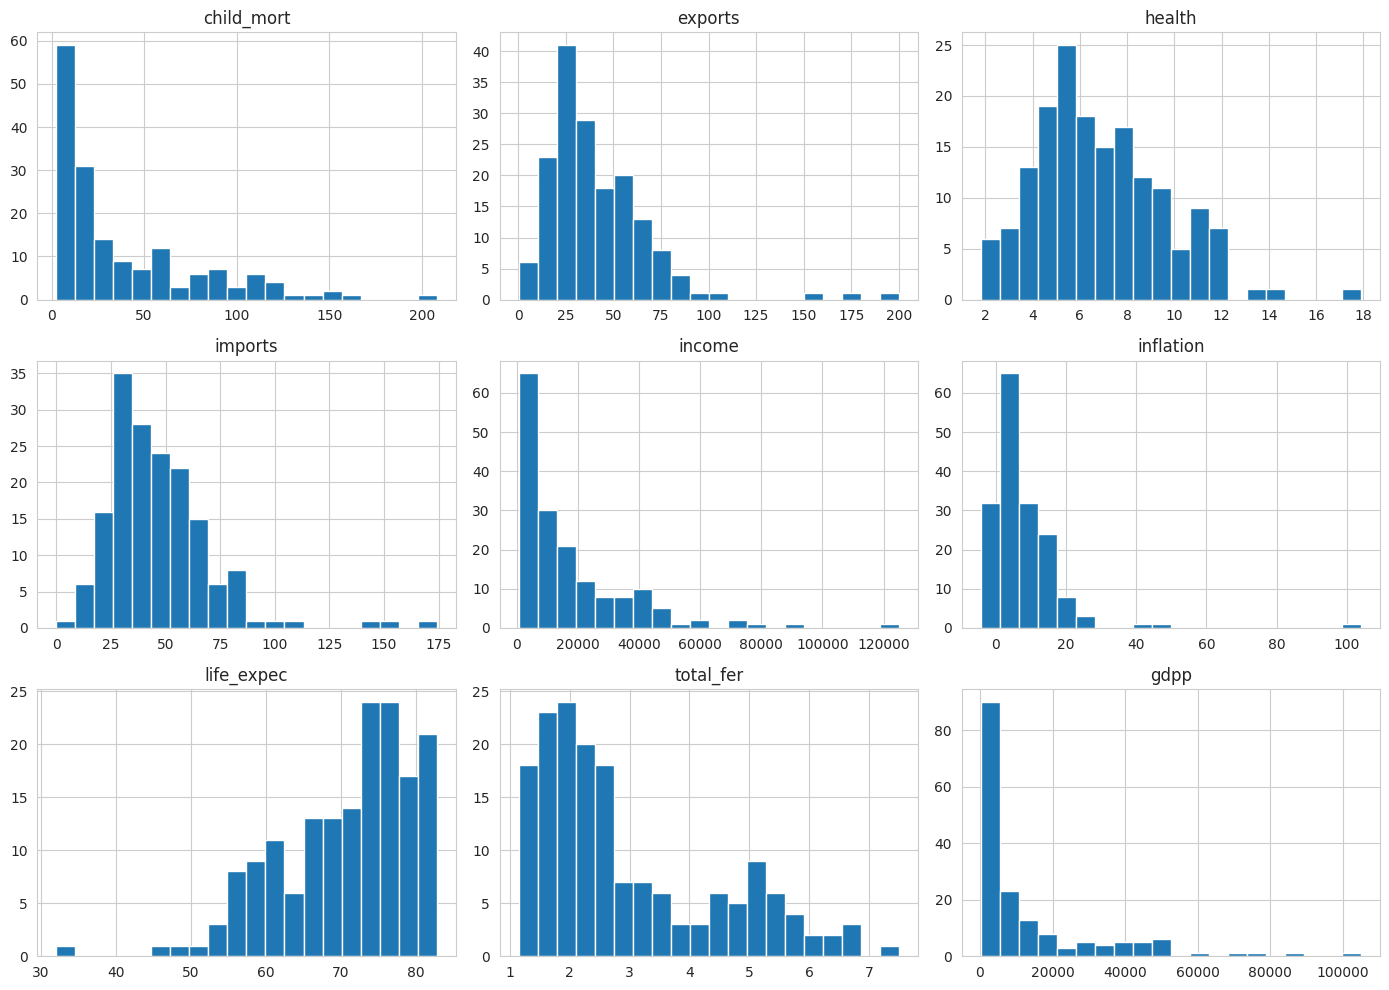

In [20]:
X_raw.hist(bins=20, figsize=(14, 10))
plt.tight_layout()
plt.show()

## 5. Feature Scaling

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled_df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


## 6. Clustering — K-Means (elbow + silhouette to pick k)

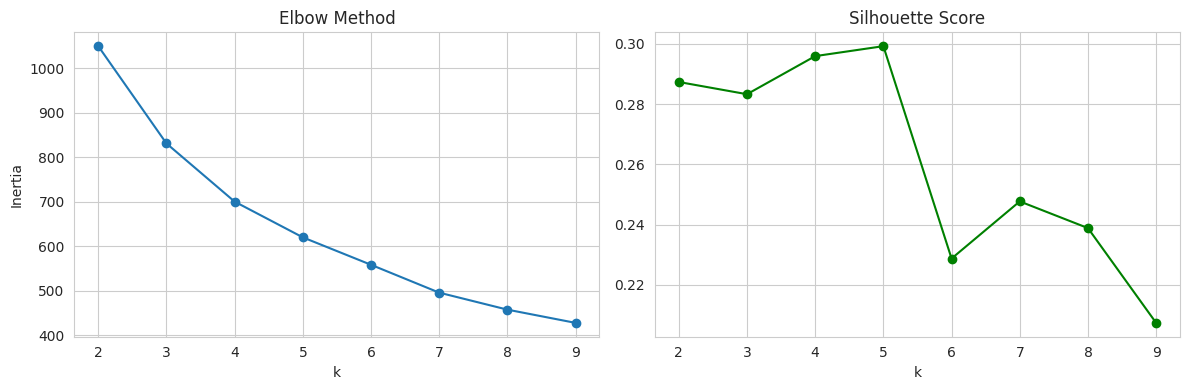

In [22]:
inertias, sil_scores = [], []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(k_range), inertias, marker="o")
ax[0].set_title("Elbow Method"); ax[0].set_xlabel("k"); ax[0].set_ylabel("Inertia")
ax[1].plot(list(k_range), sil_scores, marker="o", color="green")
ax[1].set_title("Silhouette Score"); ax[1].set_xlabel("k")
plt.tight_layout()
plt.show()

In [23]:
best_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"Selected k for K-Means: {best_k}")

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)
print("K-Means silhouette score:", silhouette_score(X_scaled, df["kmeans_cluster"]))

Selected k for K-Means: 5
K-Means silhouette score: 0.2992594995920442


## 7. Clustering — DBSCAN

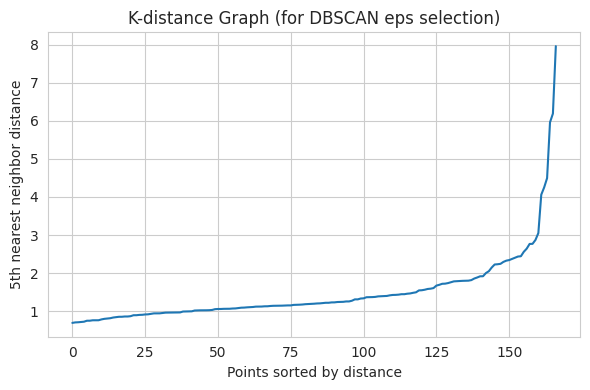

In [24]:
neighbors = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(6, 4))
plt.plot(distances)
plt.title("K-distance Graph (for DBSCAN eps selection)")
plt.xlabel("Points sorted by distance"); plt.ylabel("5th nearest neighbor distance")
plt.tight_layout()
plt.show()

In [25]:
dbscan = DBSCAN(eps=1.2, min_samples=5)
df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)
n_dbscan_clusters = len(set(df["dbscan_cluster"])) - (1 if -1 in df["dbscan_cluster"].values else 0)
print(f"DBSCAN found {n_dbscan_clusters} clusters (+ noise points labeled -1)")
df["dbscan_cluster"].value_counts()

DBSCAN found 3 clusters (+ noise points labeled -1)


,count
dbscan_cluster,
1,75
-1,53
0,21
2,18


## 8. Visualize Clusters in 2D (PCA)

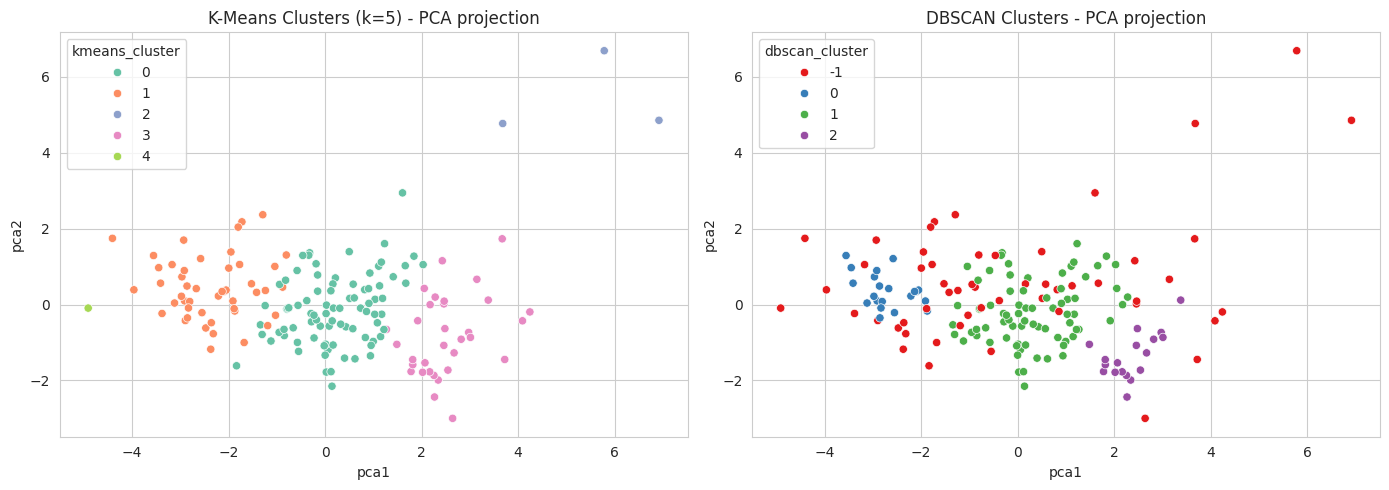

In [26]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pcs = pca.fit_transform(X_scaled)
df["pca1"], df["pca2"] = pcs[:, 0], pcs[:, 1]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x="pca1", y="pca2", hue="kmeans_cluster", palette="Set2", data=df, ax=ax[0])
ax[0].set_title(f"K-Means Clusters (k={best_k}) - PCA projection")

sns.scatterplot(x="pca1", y="pca2", hue="dbscan_cluster", palette="Set1", data=df, ax=ax[1])
ax[1].set_title("DBSCAN Clusters - PCA projection")
plt.tight_layout()
plt.show()

## 9. Segment Profiling — Business / Customer-Intelligence Labels

In [27]:
segment_profile = df.groupby("kmeans_cluster")[feature_cols].mean().round(2)
segment_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,21.61,40.98,6.17,47.52,12801.07,7.62,73.00,2.28,6581.81
1,90.79,29.66,6.46,43.68,3870.70,9.95,59.21,4.97,1900.26
2,4.13,176.00,6.79,156.67,64033.33,2.47,81.43,1.38,57566.67
3,5.18,46.12,9.09,40.58,44021.88,2.51,80.08,1.79,42118.75
4,130.00,25.30,5.07,17.40,5150.00,104.00,60.50,5.84,2330.00


In [30]:
value_rank = segment_profile[["gdpp", "income"]].mean(axis=1).sort_values()
segment_names = {}
labels_ordered = ["High-Priority / At-Risk", "Growth Potential", "Stable / High-Value"]
for i, cluster_id in enumerate(value_rank.index):
    segment_names[cluster_id] = labels_ordered[i] if i < len(labels_ordered) else f"Segment {cluster_id}"

df["segment_name"] = df["kmeans_cluster"].map(segment_names)
df["segment_name"].value_counts()

,count
segment_name,
Stable / High-Value,84
High-Priority / At-Risk,47
Segment 3,32
Segment 2,3
Growth Potential,1


## 10. Ensemble Classification — Random Forest & XGBoost




In [33]:
X = X_scaled_df.copy()
y = df["kmeans_cluster"]

# Identify clusters with only one member
class_counts = y.value_counts()
single_member_classes = class_counts[class_counts < 2].index.tolist()

if single_member_classes:
    print(f"Warning: The following KMeans clusters have less than 2 members and will be excluded from train_test_split for stratification: {single_member_classes}")
    # Filter out these classes from X and y
    indices_to_keep = ~y.isin(single_member_classes)
    X = X.loc[indices_to_keep]
    y = y.loc[indices_to_keep]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

In [34]:
# --- Random Forest ---
rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    rf_params, cv=5, scoring="f1_weighted", n_jobs=-1
)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
print("Best RF params:", rf_grid.best_params_)

rf_preds = rf_best.predict(X_test)
print("\n--- Random Forest ---")
print("Accuracy:", accuracy_score(y_test, rf_preds))
print("F1 (weighted):", f1_score(y_test, rf_preds, average="weighted"))
print(classification_report(y_test, rf_preds))

Best RF params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}

--- Random Forest ---
Accuracy: 1.0
F1 (weighted): 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         6

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



In [35]:
# --- XGBoost ---
xgb_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
}
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss"),
    xgb_params, cv=5, scoring="f1_weighted", n_jobs=-1
)
xgb_grid.fit(X_train, y_train)
xgb_best = xgb_grid.best_estimator_
print("Best XGB params:", xgb_grid.best_params_)

xgb_preds = xgb_best.predict(X_test)
print("\n--- XGBoost ---")
print("Accuracy:", accuracy_score(y_test, xgb_preds))
print("F1 (weighted):", f1_score(y_test, xgb_preds, average="weighted"))
print(classification_report(y_test, xgb_preds))

Best XGB params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300}

--- XGBoost ---
Accuracy: 0.9411764705882353
F1 (weighted): 0.9395424836601307
              precision    recall  f1-score   support

           0       0.89      1.00      0.94        17
           1       1.00      0.80      0.89        10
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         6

    accuracy                           0.94        34
   macro avg       0.97      0.95      0.96        34
weighted avg       0.95      0.94      0.94        34



## 11. Confusion Matrices & Feature Importance

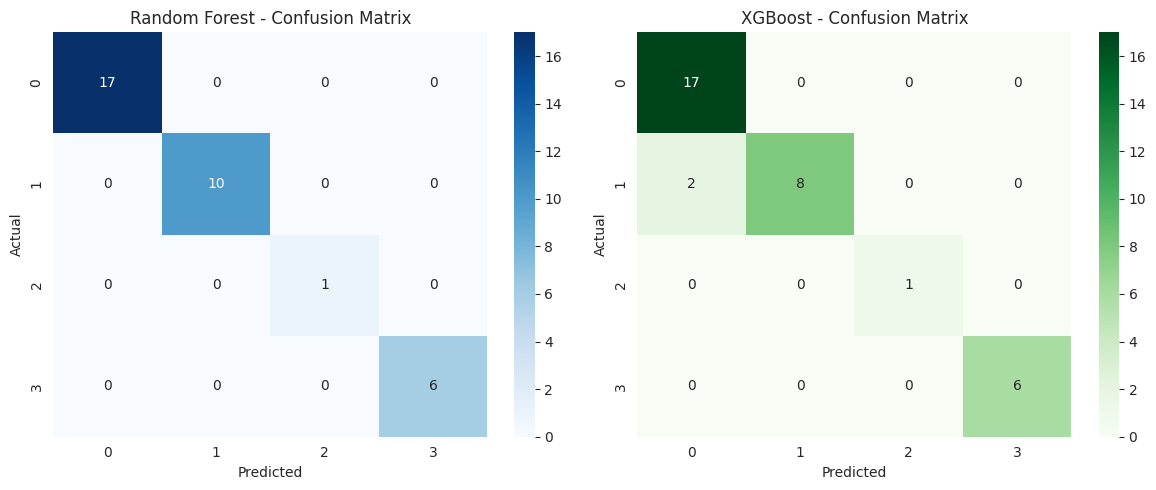

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt="d", cmap="Blues", ax=ax[0])
ax[0].set_title("Random Forest - Confusion Matrix")
ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, xgb_preds), annot=True, fmt="d", cmap="Greens", ax=ax[1])
ax[1].set_title("XGBoost - Confusion Matrix")
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("Actual")
plt.tight_layout()
plt.show()

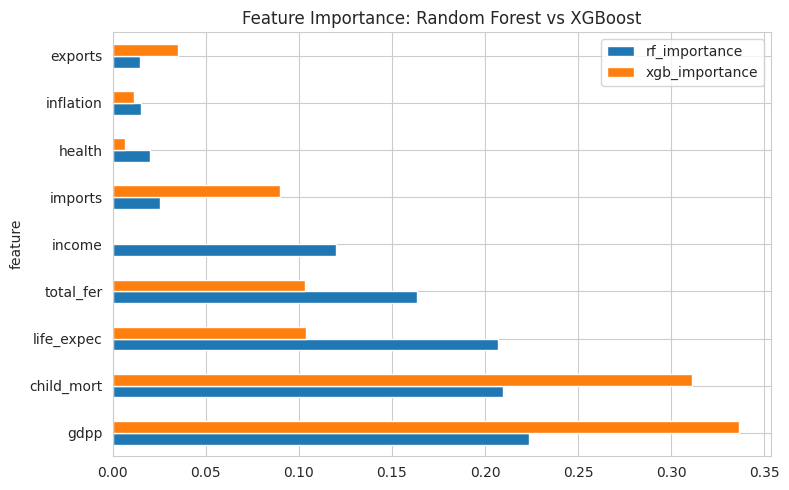

,feature,rf_importance,xgb_importance
8,gdpp,0.223578,0.336495
0,child_mort,0.209595,0.311106
6,life_expec,0.207230,0.103980
7,total_fer,0.163653,0.103476
4,income,0.120133,0.001035
3,imports,0.025483,0.089976
2,health,0.020359,0.006943
5,inflation,0.015046,0.011793
1,exports,0.014924,0.035197


In [37]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "rf_importance": rf_best.feature_importances_,
    "xgb_importance": xgb_best.feature_importances_,
}).sort_values("rf_importance", ascending=False)

importance_df.set_index("feature")[["rf_importance", "xgb_importance"]].plot(
    kind="barh", figsize=(8, 5), title="Feature Importance: Random Forest vs XGBoost"
)
plt.tight_layout()
plt.show()
importance_df

## 12. Final Model Comparison

In [38]:
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [accuracy_score(y_test, rf_preds), accuracy_score(y_test, xgb_preds)],
    "F1 (weighted)": [
        f1_score(y_test, rf_preds, average="weighted"),
        f1_score(y_test, xgb_preds, average="weighted"),
    ],
})
results

,Model,Accuracy,F1 (weighted)
0,Random Forest,1.000000,1.000000
1,XGBoost,0.941176,0.939542


## 13. Save Final Labeled Dataset

In [39]:
df.to_csv("country_data_with_segments.csv", index=False)
print("Saved: country_data_with_segments.csv")

# Optional: download it to your computer
from google.colab import files
files.download("country_data_with_segments.csv")

Saved: country_data_with_segments.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>